# Reactive Transport Calibration

This is the final notebook, and it shows the end goal of tying the hydrology and
reactive-transport models together: **calibration**. We adjust the model's
parameters - some that control the *water* (how quickly the hydrologic stores
release flow) and some that control the *chemistry* (how much carbon the soil
respiring produces) - to make the simulation match **two** sets of observations
at once: the streamflow and the river dissolved-organic-carbon concentration.

We set this up with `scipy.optimize.minimize`. The objective function is the
**negative sum of two Nash-Sutcliffe efficiencies (NSEs)** - one against
streamflow and one against river DOC - so that *minimizing* it means *maximizing*
both fits at the same time:

$$\text{objective} = -\Big( \text{NSE}_{\text{streamflow}} + \text{NSE}_{\text{DOC}} \Big)$$

NSE is our usual hydrologic goodness-of-fit (1.0 is a perfect fit, negative is
worse than the mean). Because `run_both_models` returns both the streamflow and
the DOC performance in one call, defining the objective is a few lines.

The steps are:

1. Load the input data
2. Set up the hydrology and the simple carbon network (as in notebook 6)
3. Choose the parameters to calibrate, with a name, a starting value, and a range
4. Write the simulation routine and the objective function
5. Set up (and do a short demonstration of) the optimization with `scipy.optimize.minimize`
6. View the results: what the calibration changed

For speed, this is only a *demonstration* - a few capped optimization steps -
not a full calibration (which would run far more iterations and take much
longer). It shows exactly how the optimization is wired up. This is a
Jupytext-style percent script: `# %%` and `# %% [markdown]` delimit the cells.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.axes import Axes
from matplotlib.figure import Figure
from pandas import DataFrame, Series
from scipy import optimize

import potions as pt
from potions.reactive_transport.common_networks import get_simple_carbon_network

data_dir: str = "../data"
forcing_path: str = os.path.join(data_dir, "model_inputs", "forcing.csv")
measured_path: str = os.path.join(data_dir, "model_inputs", "measured_data.csv")

## 1. Load the input data

Identical to notebook 6: the weather drivers and the two observed series
(streamflow and river DOC). Calibration compares the model to both.

In [2]:
forcing_df: DataFrame = pd.read_csv(forcing_path, index_col=0, parse_dates=True)
measured_df: DataFrame = pd.read_csv(measured_path, index_col=0, parse_dates=True)

forcing: pt.ForcingData = pt.ForcingData(
    precip=forcing_df["ppt"],
    temp=forcing_df["temp"],
    pet=forcing_df["pet"],
)

meas_streamflow: Series = measured_df["q_mmd"]
meas_river_conc: DataFrame = measured_df["doc_mol_l"].to_frame("DOC")

print(
    f"Forcing spans {forcing_df.index[0].date()} to {forcing_df.index[-1].date()} ({len(forcing_df)} days)"
)
print(
    f"Observations  spans {measured_df.index[0].date()} to {measured_df.index[-1].date()} ({len(measured_df)} days)"
)

Forcing spans 2008-10-01 to 2015-09-30 (2554 days)
Observations  spans 2009-10-01 to 2015-09-30 (2191 days)


## 2. Set up the hydrology and the simple carbon network

We reuse the simple carbon network from notebook 6 and the same four-zone
hydrology. Nothing here is new; it is simply the model we will now tune.

In [3]:
network: pt.ReactionNetwork = get_simple_carbon_network()

# NOTE: the reactive zone's water volume (porosity * depth) must exceed the
# largest storage the hydrology can hold in any zone during the *search*, not
# just at the start or the bounds. depth is chosen generously (5000 mm * 0.5 =
# 2500 mm of water) so intermediate optimizer steps never trip the water-volume
# check in the deeper stores.
zone_dimensions: pt.ZoneDimensions = pt.ZoneDimensions(
    porosity=0.5,
    depth=5_000.0,
    passive_water_storage=0.0,
)


def mineral_params_from_ssa(ssa: float, q10: float = 1.5) -> pt.MineralParameters:
    """Build the mineral parameters for a layer from a single surface-area value."""
    auxiliary: pt.MineralAuxParams = pt.MineralAuxParams(
        ssa=ssa,
        sw_threshold=0.5,
        sw_exp=1.0,
        q_10=q10,
    )
    return pt.MineralParameters.from_mineral_parameters([auxiliary])


# The initial chemical state (solid carbon in each reacting zone), fixed throughout.
init_conc: dict[str, pt.ChemicalState] = {
    "surface": pt.ChemicalState(mineral={"SOC(s)": 1.0}, primary={"DOC": 1e-3}),
    "shallow": pt.ChemicalState(mineral={"SOC(s)": 0.1}, primary={"DOC": 1e-3}),
    "deep": pt.ChemicalState(mineral={"SOC(s)": 0.01}, primary={"DOC": 1e-3}),
}

print("Network species:", network.species_names)
print("Initial solid carbon in zones:", list(init_conc.keys()))

Network species: ['DOC', 'SOC(s)']
Initial solid carbon in zones: ['surface', 'shallow', 'deep']


## 3. Choose the parameters to calibrate

An optimizer works with a **numerical vector** of values, so we decide which
model parameters to tune and lay them out in a fixed order, each with:

- a **name** (so we can read the result back),
- a **starting value** (the initial guess, the `x0` the optimizer begins from),
- an **admissible range** (a lower and upper bound that keeps the values physical).

We mix **hydrologic** parameters (snow-melt threshold and max melt, surface
field capacity and threshold, and the two groundwater recession constants) with
**chemical** parameters (the specific surface area `ssa` that drives
respiration in each reacting layer). These are the levers that shape,
respectively, the streamflow and the DOC.

All values are held in their *natural* units. Because the surface area `ssa`
can vary by orders of magnitude between layers, we simply allow a wide range
(down to `1e-4`) so the optimizer can reach both fast and slow respiration.

In [4]:
# A dataclass-free, ordered description of the calibration vector. Each row is a
# parameter name, its starting value, its lower bound, and its upper bound. All
# values are in the parameter's *natural* space (not log).
param_names: list[str] = [
    "snow.tt",
    "snow.fmax",
    "surface.fc",
    "surface.thr",
    "shallow.k",
    "deep.k",
    "min.surface.ssa",  # specific surface area of SOC in the surface layer
    "min.shallow.ssa",
    "min.deep.ssa",
]

# Starting values (x0), aligned to param_names.
x0_values: list[float] = [
    0.5,  # snow.tt        - threshold temperature (deg C)
    2.0,  # snow.fmax      - max daily melt (mm/deg C)
    250.0,  # surface.fc     - field capacity (mm)
    25.0,  # surface.thr    - quick-runoff threshold (mm)
    2.0e-2,  # shallow.k      - shallow groundwater recession (1/day)
    1.0e-3,  # deep.k         - deep groundwater recession (1/day)
    1.0,  # min.surface.ssa
    0.1,  # min.shallow.ssa
    1.0e-2,  # min.deep.ssa
]

# Admissible lower and upper bounds, aligned to param_names. The groundwater
# recessions are floored (not quite zero) so the optimizer cannot push a store
# toward "permanent", which would make the water stores arbitrarily deep and
# overflow the reactive zone's finite water volume.
bounds_values: list[tuple[float, float]] = [
    (0.0, 5.0),  # snow.tt
    (0.1, 8.0),  # snow.fmax
    (50.0, 600.0),  # surface.fc
    (1.0, 100.0),  # surface.thr
    (2.0e-3, 1.0),  # shallow.k
    (1.0e-3, 1.0),  # deep.k
    (1.0e-2, 1.0),  # min.surface.ssa
    (1.0e-4, 1.0),  # min.shallow.ssa
    (1.0e-4, 1.0),  # min.deep.ssa
]

x0: np.ndarray = np.asarray(x0_values, dtype=np.float64)
bounds: list[tuple[float, float]] = bounds_values

print(f"Calibrating {len(param_names)} parameters:")
for name, start, (lo, hi) in zip(param_names, x0_values, bounds_values):
    print(f"   {name:<18} start={start:.4g}   range=[{lo:.4g}, {hi:.4g}]")

Calibrating 9 parameters:
   snow.tt            start=0.5   range=[0, 5]
   snow.fmax          start=2   range=[0.1, 8]
   surface.fc         start=250   range=[50, 600]
   surface.thr        start=25   range=[1, 100]
   shallow.k          start=0.02   range=[0.002, 1]
   deep.k             start=0.001   range=[0.001, 1]
   min.surface.ssa    start=1   range=[0.01, 1]
   min.shallow.ssa    start=0.1   range=[0.0001, 1]
   min.deep.ssa       start=0.01   range=[0.0001, 1]


## 4. Write the simulation routine and the objective function

Every evaluation by the optimizer does the same three things:

1. Take a candidate parameter vector `x` and **build** a full reactive model
   from it (map the vector back onto the zone and mineral parameters).
2. **Run** it with `run_both_models`.
3. **Read out** the two NSEs - streamflow from the hydro result, DOC from the
   reactive result - and return the negative sum as a single number to minimize.

`run_both_models` returns a `ModelResults` whose `.hydro` part carries the
streamflow metrics (a `Series`) and whose `.reactive_transport` part carries a
per-species metrics table (a `DataFrame`), so pulling the two NSEs is a couple
of lookups.

In [5]:
def build_model(
    x: np.ndarray, zone_dims: pt.ZoneDimensions, net: pt.ReactionNetwork
) -> pt.HbvModel:
    """Build a full reactive model from a candidate parameter vector.

    The vector is interpreted in the fixed order of ``param_names``: six
    hydrologic parameters followed by three chemical surface-area values.
    """
    snow_tt: float = x[0]
    snow_fmax: float = x[1]
    surf_fc: float = x[2]
    surf_thr: float = x[3]
    shallow_k: float = x[4]
    deep_k: float = x[5]
    surf_ssa: float = x[6]
    shallow_ssa: float = x[7]
    deep_ssa: float = x[8]

    # Map the vector onto the hydrologic zones.
    custom_zones: dict[str, pt.HydrologicZone] = {
        "snow": pt.SnowZone(tt=snow_tt, fmax=snow_fmax),
        "surface": pt.SurfaceZone(fc=surf_fc, thr=surf_thr),
        "shallow": pt.SubsurfaceZone(k=shallow_k, perc=0.5),
        "deep": pt.SubsurfaceZone(k=deep_k, alpha=1.0),
    }

    # Map the vector onto the per-zone chemical parameters.
    rt_zones: dict[str, pt.RtZone] = {
        "snow": pt.RtZone(
            net,
            pt.RtParameters(dimensions=zone_dims, mineral_params=None),
            do_reactions=False,
            do_speciation=False,
            name="snow",
        ),
        "surface": pt.RtZone(
            net,
            pt.RtParameters(
                dimensions=zone_dims, mineral_params=mineral_params_from_ssa(surf_ssa)
            ),
            name="surface",
        ),
        "shallow": pt.RtZone(
            net,
            pt.RtParameters(
                dimensions=zone_dims,
                mineral_params=mineral_params_from_ssa(shallow_ssa),
            ),
            name="shallow",
        ),
        "deep": pt.RtZone(
            net,
            pt.RtParameters(
                dimensions=zone_dims, mineral_params=mineral_params_from_ssa(deep_ssa)
            ),
            name="deep",
        ),
    }

    return pt.HbvModel(zones=custom_zones, network=net, rt_zones=rt_zones)


def run_model(
    x: np.ndarray, zone_dims: pt.ZoneDimensions, net: pt.ReactionNetwork
) -> pt.ModelResults:
    """Run the reactive model for one candidate vector of parameters."""
    model: pt.HbvModel = build_model(x, zone_dims, net)

    # A near-zero incoming DOC load, one surface zone, two species (DOC, SOC(s)).
    precip_conc: np.ndarray = np.full(
        (1, len(forcing.precip), net.num_species), fill_value=1e-20, dtype=np.float64
    )

    return model.run_both_models(
        forc=forcing,
        precip_conc=precip_conc,
        init_conc=init_conc,
        meas_streamflow=meas_streamflow,
        meas_river_conc=meas_river_conc,
    )


def objective(x: np.ndarray) -> float:
    """The objective to minimize: the negative sum of NSE(streamflow) and NSE(DOC).

    `scipy.optimize.minimize` hands us a single parameter vector, so this closes
    over the shared `zone_dimensions` and `network` objects from the notebook.
    """
    results: pt.ModelResults = run_model(x, zone_dimensions, network)

    nse_streamflow: float = float(results.hydro.objective_functions["nse"])
    nse_doc: float = float(
        results.reactive_transport.objective_functions.loc["DOC", "nse"]
    )

    return -(nse_streamflow + nse_doc)


# Evaluate the starting point once so we can report how much the calibration later
# improves on it.
initial_objective: float = objective(x0)
print(f"Objective at the starting parameters: {initial_objective:.4f}")

Objective at the starting parameters: 8.5085


## 5. Set up the optimization with `scipy.optimize.minimize`

We use the bounded **L-BFGS-B** method, which is a good default for a smooth,
low-dimensional objective with simple box constraints. We deliberately cap the
number of iterations and function-evaluations so that this demonstration runs in
seconds - just enough steps to *show* the objective decreasing and the
parameters moving. A real calibration would be allowed to run much longer (and
would typically use more robust methods such as differential evolution or a
multi-start scheme over this smooth local one).

In [6]:
def run_calibration(
    x0: np.ndarray, bounds: list[tuple[float, float]]
) -> optimize.OptimizeResult:
    """Run the bounded optimization on the two-objective NSE sum.

    For this demonstration the iteration and function-evaluation counts are capped
    so it returns quickly; raise them (or remove the caps) to run a full
    calibration.
    """
    result: optimize.OptimizeResult = optimize.minimize(
        fun=objective,
        x0=x0,
        method="L-BFGS-B",
        bounds=bounds,
        options={"maxiter": 3, "maxfun": 12},  # capped for the demo
    )
    return result


calibration_result: optimize.OptimizeResult = run_calibration(x0, bounds)

calibrated_x: np.ndarray = np.asarray(calibration_result.x, dtype=np.float64)
final_objective: float = float(calibration_result.fun)
num_evaluations: int = int(calibration_result.nfev)

print(
    f"Optimizer finished after {num_evaluations} function evaluations "
    f"(capped at {calibration_result.nit} iterations)."
)
print(f"Objective at start: {initial_objective:.4f}")
print(f"Objective at end:   {final_objective:.4f}")
print(f"Improvement (start - end): {initial_objective - final_objective:.4f}")

Optimizer finished after 20 function evaluations (capped at 1 iterations).
Objective at start: 8.5085
Objective at end:   6.5966
Improvement (start - end): 1.9119


## 6. See what the calibration did

First we read the parameter values at the start and after calibration, then we
re-run the model with the start and the calibrated vectors so we can compare the
two fits to the observations side by side.

In [7]:
param_changes: DataFrame = pd.DataFrame(
    {
        "parameter": param_names,
        "start": x0,
        "calibrated": calibrated_x,
        "changed": x0 != calibrated_x,
    }
)
print("Parameters at the start vs. after calibration:")
print(param_changes.to_string(index=False))
print()

# ---- Re-run both endpoints for the plots ---- #
start_results: pt.ModelResults = run_model(x0, zone_dimensions, network)
calibrated_results: pt.ModelResults = run_model(calibrated_x, zone_dimensions, network)

start_nse_q: float = float(start_results.hydro.objective_functions["nse"])
start_nse_c: float = float(
    start_results.reactive_transport.objective_functions.loc["DOC", "nse"]
)
end_nse_q: float = float(calibrated_results.hydro.objective_functions["nse"])
end_nse_c: float = float(
    calibrated_results.reactive_transport.objective_functions.loc["DOC", "nse"]
)

print("Performance metrics, start vs. calibrated:")
print(f"   Streamflow  NSE: {start_nse_q:.4f}  ->  {end_nse_q:.4f}")
print(f"           DOC   NSE: {start_nse_c:.4f}  ->  {end_nse_c:.4f}")

Parameters at the start vs. after calibration:
      parameter   start  calibrated  changed
        snow.tt   0.500    1.436588     True
      snow.fmax   2.000    1.048281     True
     surface.fc 250.000  249.999225     True
    surface.thr  25.000   25.060295     True
      shallow.k   0.020    0.002000     True
         deep.k   0.001    1.000000     True
min.surface.ssa   1.000    0.999261     True
min.shallow.ssa   0.100    0.099973     True
   min.deep.ssa   0.010    0.010000    False

Performance metrics, start vs. calibrated:
   Streamflow  NSE: 0.1644  ->  0.1111
           DOC   NSE: -8.6729  ->  -6.7077


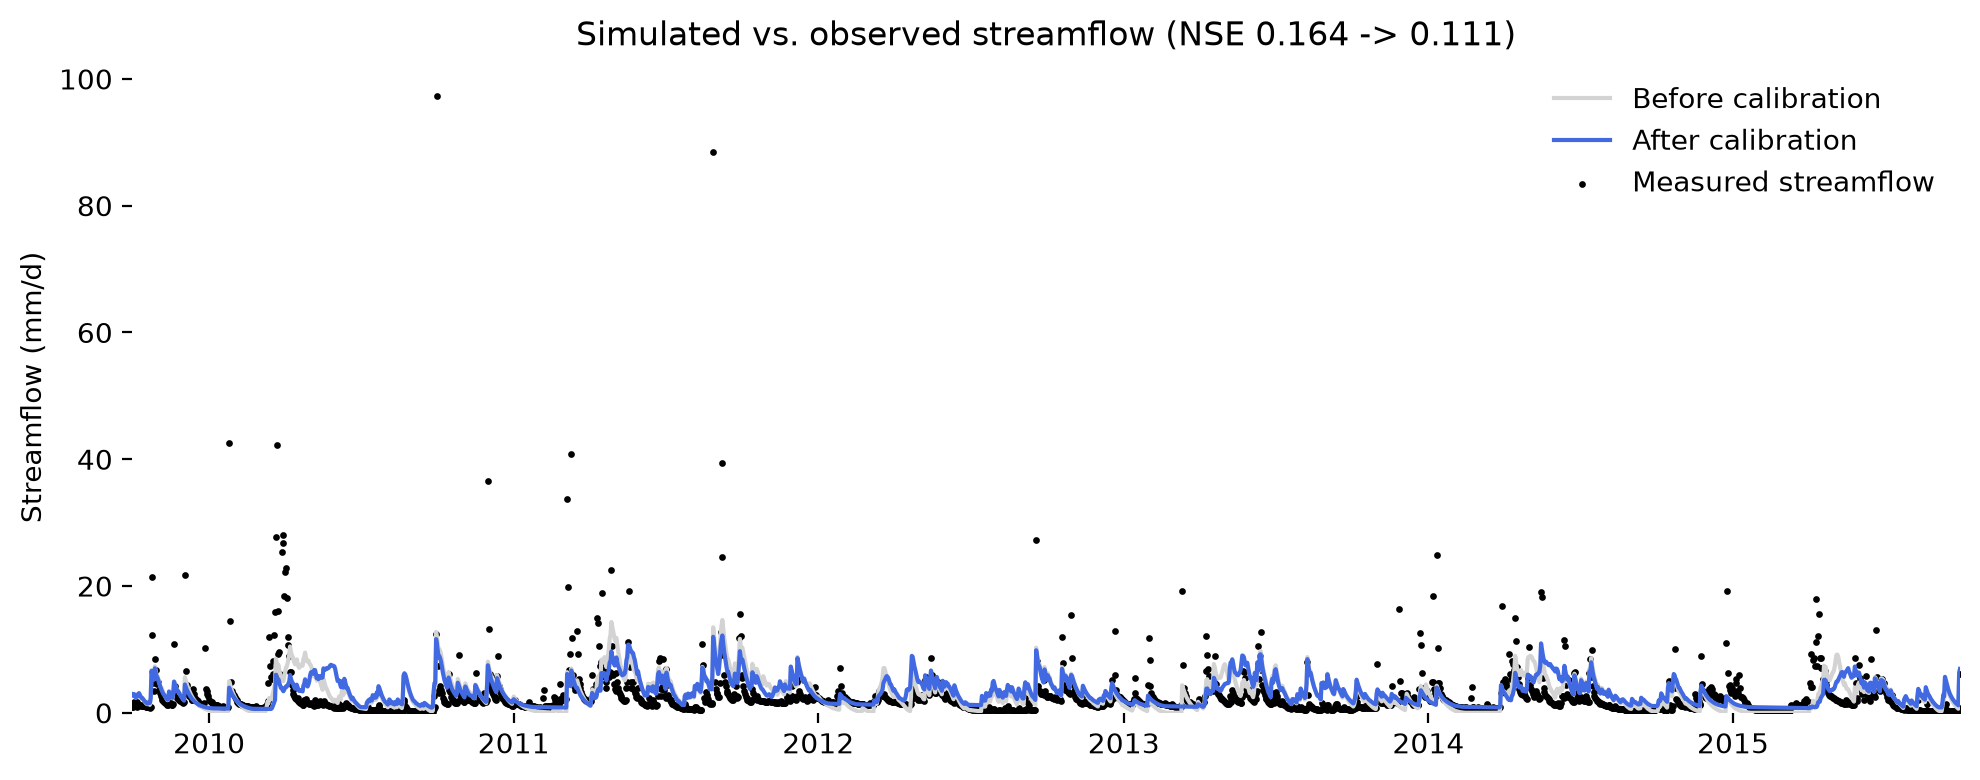

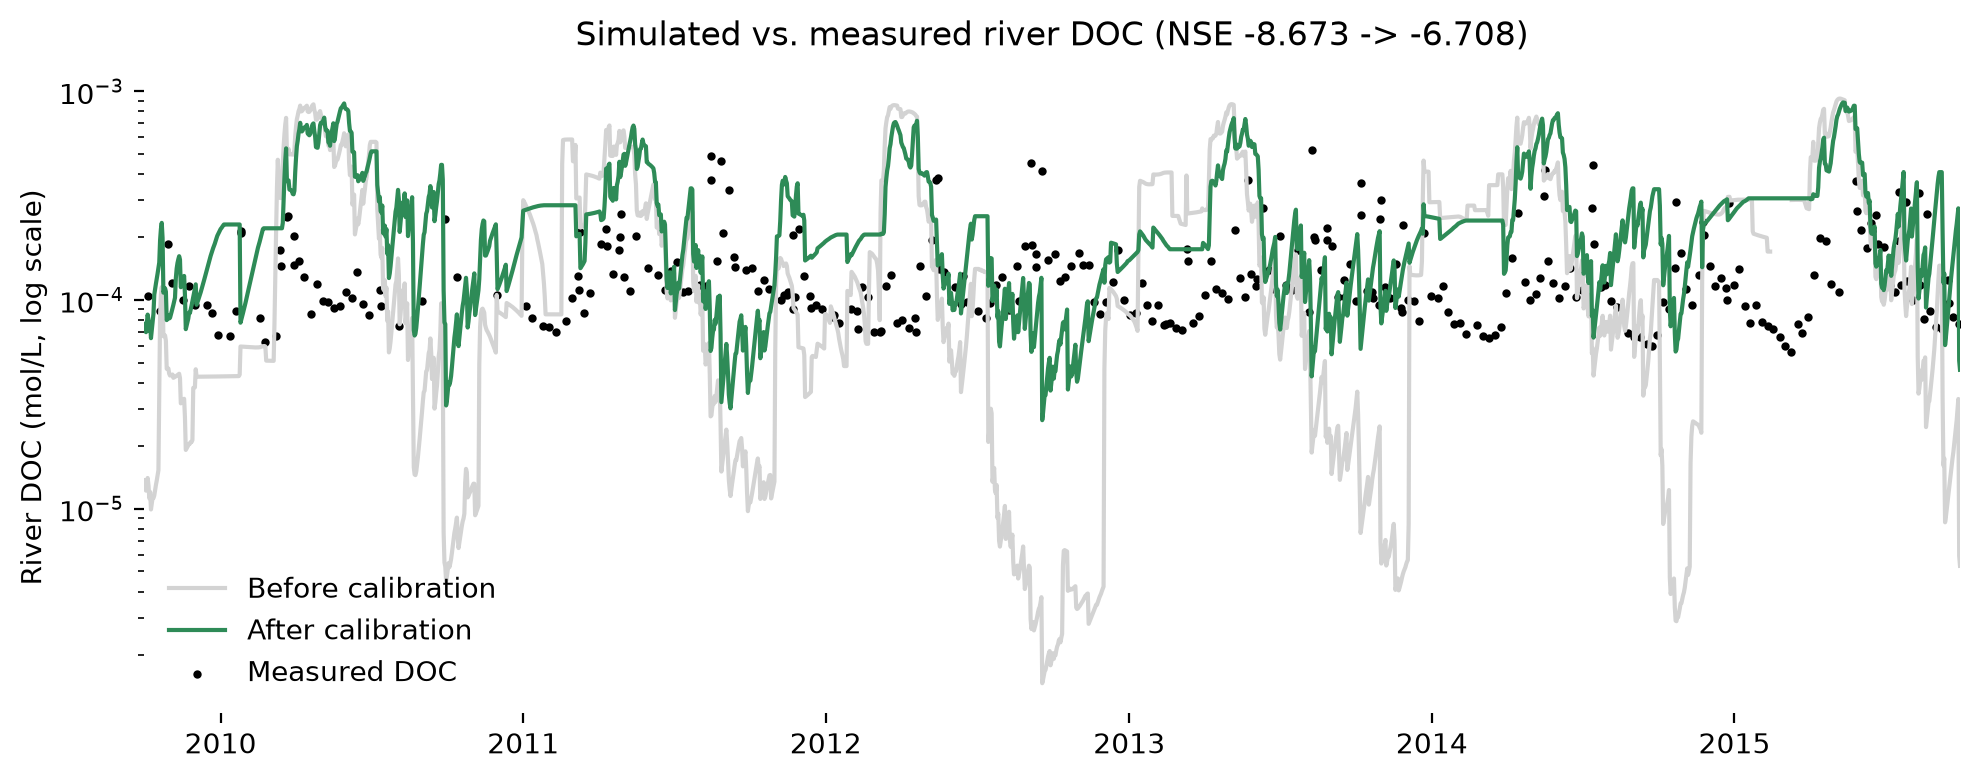

Calibration demonstration complete. To run a fuller calibration, raise the
`maxiter` / `maxfun` caps in `run_calibration()` above.


In [8]:
plt.rcParams["figure.dpi"] = 200
plt.rcParams["legend.frameon"] = False
plt.rcParams["axes.spines.bottom"] = False
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.left"] = False
plt.rcParams["axes.spines.right"] = False

obs_start: pd.Timestamp = meas_streamflow.index[0]
obs_end: pd.Timestamp = meas_streamflow.index[-1]
doc_obs: Series = meas_river_conc["DOC"]

start_hydro: DataFrame = start_results.hydro.simulation
start_rt: DataFrame = start_results.reactive_transport.simulation
cal_hydro: DataFrame = calibrated_results.hydro.simulation
cal_rt: DataFrame = calibrated_results.reactive_transport.simulation

# ---- Panel 1: streamflow, start vs. calibrated ---- #
fig: Figure = plt.figure(figsize=(10, 4))
ax: Axes = fig.gca()

ax.plot(
    start_hydro.index,
    start_hydro["streamflow_sim"],
    color="lightgray",
    label="Before calibration",
)
ax.plot(
    cal_hydro.index,
    cal_hydro["streamflow_sim"],
    color="royalblue",
    label="After calibration",
)
ax.scatter(
    meas_streamflow.index,
    meas_streamflow,
    s=2,
    color="black",
    label="Measured streamflow",
)
ax.set_xlim(obs_start, obs_end)
ax.set_ylim(
    0,
    max(
        start_hydro["streamflow_sim"].quantile(0.99),
        cal_hydro["streamflow_sim"].quantile(0.99),
    )
    * 10,
)
ax.set_ylabel("Streamflow (mm/d)")
ax.set_title(
    f"Simulated vs. observed streamflow (NSE {start_nse_q:.3f} -> {end_nse_q:.3f})"
)
ax.legend()
fig.tight_layout()
plt.show()

# ---- Panel 2: river DOC, start vs. calibrated ---- #
fig2: Figure = plt.figure(figsize=(10, 4))
ax2: Axes = fig2.gca()

ax2.plot(
    start_rt.index, start_rt["DOC_riv"], color="lightgray", label="Before calibration"
)
ax2.plot(cal_rt.index, cal_rt["DOC_riv"], color="seagreen", label="After calibration")
ax2.scatter(doc_obs.index, doc_obs, s=4, color="black", label="Measured DOC")
ax2.set_yscale("log")
ax2.set_xlim(obs_start, obs_end)
ax2.set_ylabel("River DOC (mol/L, log scale)")
ax2.set_title(
    f"Simulated vs. measured river DOC (NSE {start_nse_c:.3f} -> {end_nse_c:.3f})"
)
ax2.legend()
fig2.tight_layout()
plt.show()

print("Calibration demonstration complete. To run a fuller calibration, raise the")
print("`maxiter` / `maxfun` caps in `run_calibration()` above.")